# EDA US Stocks 2020-2024

## Brief Introduction to The Stock Market

### Stocks and Assets

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import scipy.stats as stats
import sklearn.linear_model as linear_model
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import KFold
from IPython.display import HTML, display
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

stocks = pd.read_csv("C:/Users/ckhin/OneDrive/Documents/GitHub/MATB-STUDIOS/US Stock Market Dataset.csv")
stocks.head()

,Unnamed: 0,Date,Natural_Gas_Price,Natural_Gas_Vol.,Crude_oil_Price,Crude_oil_Vol.,Copper_Price,Copper_Vol.,Bitcoin_Price,Bitcoin_Vol.,...,Berkshire_Price,Berkshire_Vol.,Netflix_Price,Netflix_Vol.,Amazon_Price,Amazon_Vol.,Meta_Price,Meta_Vol.,Gold_Price,Gold_Vol.
0,0,2/2/2024,2.079,NaN,72.28,NaN,3.8215,NaN,"43,194.70",42650,...,"5,89,498",10580,564.64,4030000,171.81,117220000,474.99,84710000,"2,053.70",NaN
1,1,1/2/2024,2.050,161340.0,73.82,577940.0,3.8535,NaN,"43,081.40",47690,...,"5,81,600",9780,567.51,3150000,159.28,66360000,394.78,25140000,"2,071.10",260920.0
2,2,31-01-2024,2.100,142860.0,75.85,344490.0,3.9060,NaN,"42,580.50",56480,...,"5,78,020",9720,564.11,4830000,155.20,49690000,390.14,20010000,"2,067.40",238370.0
3,3,30-01-2024,2.077,139750.0,77.82,347240.0,3.9110,NaN,"42,946.20",55130,...,"5,84,680",9750,562.85,6120000,159.00,42290000,400.06,18610000,"2,050.90",214590.0
4,4,29-01-2024,2.490,3590.0,76.78,331930.0,3.8790,NaN,"43,299.80",45230,...,"5,78,800",13850,575.79,6880000,161.26,42840000,401.02,17790000,"2,034.90",1780.0


In [2]:
pd.options.display.max_rows = 1000
pd.options.display.max_columns = 20

## Data Cleaning

Data cleaning is a process

In [3]:
#output basic info on the dataset
stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1013 entries, 0 to 1012
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1013 non-null   int64  
 1   Date               1013 non-null   object 
 2   Natural_Gas_Price  1013 non-null   float64
 3   Natural_Gas_Vol.   1009 non-null   float64
 4   Crude_oil_Price    1013 non-null   float64
 5   Crude_oil_Vol.     990 non-null    float64
 6   Copper_Price       1013 non-null   float64
 7   Copper_Vol.        976 non-null    float64
 8   Bitcoin_Price      1013 non-null   object 
 9   Bitcoin_Vol.       1013 non-null   int64  
 10  Platinum_Price     1013 non-null   object 
 11  Platinum_Vol.      636 non-null    float64
 12  Ethereum_Price     1013 non-null   object 
 13  Ethereum_Vol.      1013 non-null   int64  
 14  S&P_500_Price      1013 non-null   object 
 15  Nasdaq_100_Price   1013 non-null   object 
 16  Nasdaq_100_Vol.    1012 

From the summary of the dataset, there is an error where all of the columns are supposed to be numerical, but some are labelled as categorical data. We attempt to debug this by changing the data types manually.

In [4]:
for col in stocks.columns:
    if stocks[col].dtype == 'object' and col != 'Date':
        stocks[col] = pd.Categorical(stocks[col]).codes #changing categorical labels to numerical

stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1013 entries, 0 to 1012
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1013 non-null   int64  
 1   Date               1013 non-null   object 
 2   Natural_Gas_Price  1013 non-null   float64
 3   Natural_Gas_Vol.   1009 non-null   float64
 4   Crude_oil_Price    1013 non-null   float64
 5   Crude_oil_Vol.     990 non-null    float64
 6   Copper_Price       1013 non-null   float64
 7   Copper_Vol.        976 non-null    float64
 8   Bitcoin_Price      1013 non-null   int16  
 9   Bitcoin_Vol.       1013 non-null   int64  
 10  Platinum_Price     1013 non-null   int16  
 11  Platinum_Vol.      636 non-null    float64
 12  Ethereum_Price     1013 non-null   int16  
 13  Ethereum_Vol.      1013 non-null   int64  
 14  S&P_500_Price      1013 non-null   int16  
 15  Nasdaq_100_Price   1013 non-null   int16  
 16  Nasdaq_100_Vol.    1012 

Normally this practice is not encouraged when working with data that includes actual categorical data, we implemented this approach because we are highly aware that the dataset composes of numerical data only. `Date` will remain as `object` so that after we performed KNN imputation we are able to merge. There are 1013 samples from the population. We chose to sample 70% of the dataset as the training set for our model. The rest of the 30% will be tested against our trained data to determine the model's predictability.

Unnamed: 0             0
Date                   0
Natural_Gas_Price      0
Natural_Gas_Vol.       4
Crude_oil_Price        0
Crude_oil_Vol.        23
Copper_Price           0
Copper_Vol.           37
Bitcoin_Price          0
Bitcoin_Vol.           0
Platinum_Price         0
Platinum_Vol.        377
Ethereum_Price         0
Ethereum_Vol.          0
S&P_500_Price          0
Nasdaq_100_Price       0
Nasdaq_100_Vol.        1
Apple_Price            0
Apple_Vol.             0
Tesla_Price            0
Tesla_Vol.             0
Microsoft_Price        0
Microsoft_Vol.         0
Silver_Price           0
Silver_Vol.           46
Google_Price           0
Google_Vol.            0
Nvidia_Price           0
Nvidia_Vol.            0
Berkshire_Price        0
Berkshire_Vol.         0
Netflix_Price          0
Netflix_Vol.           0
Amazon_Price           0
Amazon_Vol.            0
Meta_Price             0
Meta_Vol.              0
Gold_Price             0
Gold_Vol.              2
dtype: int64


((7,), <Axes: >)

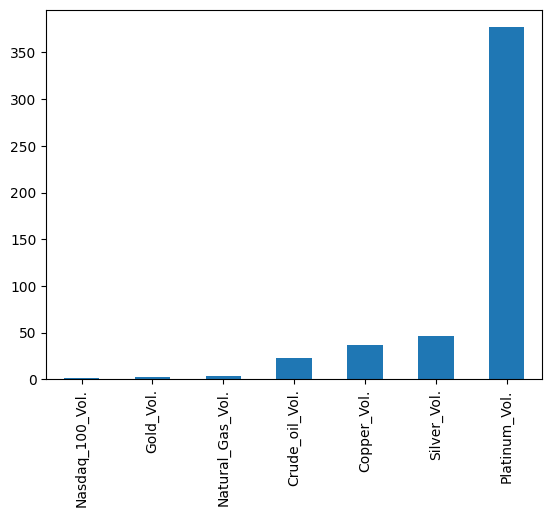

In [5]:
missing = stocks.isnull().sum() #sum up all the missing columns in a row
print(missing)
missing = missing[missing>0] #only shows missing data that are prevalent
missing.sort_values(inplace = True) #ordered sort

missing.shape, missing.plot.bar()

Evidently, there are 7 stocks / assets that have missing data with Platinum as the leading asset for most missing data. A newsletter claims that investors are losing interest in the metal due to global shortage of platinum. One of the potential reasons that may have caused the crisis includes frequent electricity cuts on South Africa, the country with the most platinum output ([Source](https://www.nasdaq.com/articles/why-does-platinum-keep-failing)). Nonetheless, Our approach to handling missing data is to perform K-Nearest Neighbours Algorithm (KNN) and fill up data that is missing.

### [K-Nearest Neighbours Algorithm (KNN)](https://www.ibm.com/topics/knn)

KNN is a supervised, non-parametric machine learning model that groups data with similar characteristics, providing predictions based on nearest euclidean distance (Note that not every classification task uses euclidean distance, alternative metrics are available) (Zhang et al, 2017). 

- supervised: Series of input and output data is first specified prior to performing actual predictions
- non-parametric: Makes limited assumptions about the underlying data

We start off by selecting columns with numerical data only.

In [6]:
numeric_columns = stocks.select_dtypes(include = [np.number, 'float']).columns.to_list()
selected_stocks = stocks[numeric_columns]

Furthermore, we apply KNN Imputer to fill in missing data:

In [7]:
knn = KNNImputer(n_neighbors = 5)
filled_stocks = knn.fit_transform(selected_stocks)
filled_df = pd.DataFrame(filled_stocks, columns = numeric_columns)

In [8]:
filled_df.head()

,Unnamed: 0,Natural_Gas_Price,Natural_Gas_Vol.,Crude_oil_Price,Crude_oil_Vol.,Copper_Price,Copper_Vol.,Bitcoin_Price,Bitcoin_Vol.,Platinum_Price,...,Berkshire_Price,Berkshire_Vol.,Netflix_Price,Netflix_Vol.,Amazon_Price,Amazon_Vol.,Meta_Price,Meta_Vol.,Gold_Price,Gold_Vol.
0,0.0,2.079,103180.0,72.28,341868.0,3.8215,57098.0,677.0,42650.0,546.0,...,990.0,10580.0,564.64,4030000.0,171.81,117220000.0,474.99,84710000.0,886.0,190762.0
1,1.0,2.050,161340.0,73.82,577940.0,3.8535,34040.0,672.0,47690.0,622.0,...,987.0,9780.0,567.51,3150000.0,159.28,66360000.0,394.78,25140000.0,895.0,260920.0
2,2.0,2.100,142860.0,75.85,344490.0,3.9060,89628.0,656.0,56480.0,662.0,...,985.0,9720.0,564.11,4830000.0,155.20,49690000.0,390.14,20010000.0,893.0,238370.0
3,3.0,2.077,139750.0,77.82,347240.0,3.9110,78758.0,669.0,55130.0,658.0,...,989.0,9750.0,562.85,6120000.0,159.00,42290000.0,400.06,18610000.0,885.0,214590.0
4,4.0,2.490,3590.0,76.78,331930.0,3.8790,76524.0,679.0,45230.0,686.0,...,986.0,13850.0,575.79,6880000.0,161.26,42840000.0,401.02,17790000.0,863.0,1780.0


In [9]:
filled_df.isnull().sum()

Unnamed: 0           0
Natural_Gas_Price    0
Natural_Gas_Vol.     0
Crude_oil_Price      0
Crude_oil_Vol.       0
Copper_Price         0
Copper_Vol.          0
Bitcoin_Price        0
Bitcoin_Vol.         0
Platinum_Price       0
Platinum_Vol.        0
Ethereum_Price       0
Ethereum_Vol.        0
S&P_500_Price        0
Nasdaq_100_Price     0
Nasdaq_100_Vol.      0
Apple_Price          0
Apple_Vol.           0
Tesla_Price          0
Tesla_Vol.           0
Microsoft_Price      0
Microsoft_Vol.       0
Silver_Price         0
Silver_Vol.          0
Google_Price         0
Google_Vol.          0
Nvidia_Price         0
Nvidia_Vol.          0
Berkshire_Price      0
Berkshire_Vol.       0
Netflix_Price        0
Netflix_Vol.         0
Amazon_Price         0
Amazon_Vol.          0
Meta_Price           0
Meta_Vol.            0
Gold_Price           0
Gold_Vol.            0
dtype: int64

As we can see, the missing columns in the dataset are repaired and filled through clustering using KNN. Now we just have to merge this section of the data with the `Date`.

In [10]:
non_numerical_columns = stocks.select_dtypes(exclude=['number']).columns #select columns that aren't numerical
if len(non_numerical_columns) > 0:
    final_imputed_data = pd.concat([stocks[non_numerical_columns], filled_df], axis=1)
else:
    final_imputed_data = filled_df

final_imputed_data.head()

,Date,Unnamed: 0,Natural_Gas_Price,Natural_Gas_Vol.,Crude_oil_Price,Crude_oil_Vol.,Copper_Price,Copper_Vol.,Bitcoin_Price,Bitcoin_Vol.,...,Berkshire_Price,Berkshire_Vol.,Netflix_Price,Netflix_Vol.,Amazon_Price,Amazon_Vol.,Meta_Price,Meta_Vol.,Gold_Price,Gold_Vol.
0,2/2/2024,0.0,2.079,103180.0,72.28,341868.0,3.8215,57098.0,677.0,42650.0,...,990.0,10580.0,564.64,4030000.0,171.81,117220000.0,474.99,84710000.0,886.0,190762.0
1,1/2/2024,1.0,2.050,161340.0,73.82,577940.0,3.8535,34040.0,672.0,47690.0,...,987.0,9780.0,567.51,3150000.0,159.28,66360000.0,394.78,25140000.0,895.0,260920.0
2,31-01-2024,2.0,2.100,142860.0,75.85,344490.0,3.9060,89628.0,656.0,56480.0,...,985.0,9720.0,564.11,4830000.0,155.20,49690000.0,390.14,20010000.0,893.0,238370.0
3,30-01-2024,3.0,2.077,139750.0,77.82,347240.0,3.9110,78758.0,669.0,55130.0,...,989.0,9750.0,562.85,6120000.0,159.00,42290000.0,400.06,18610000.0,885.0,214590.0
4,29-01-2024,4.0,2.490,3590.0,76.78,331930.0,3.8790,76524.0,679.0,45230.0,...,986.0,13850.0,575.79,6880000.0,161.26,42840000.0,401.02,17790000.0,863.0,1780.0


In [11]:
final_imputed_data.to_csv('final_imputed.csv', index=False)

## Performing EDA

### Preliminary Analysis

We will create a dataframe `stocks_updated` and drop the id column which will left us with the dates, prices as well as volumes for each stocks and assets.

In [12]:
stocks_updated = pd.read_csv("C:/Users/ckhin/OneDrive/Documents/GitHub/MATB-STUDIOS/final_imputed.csv")
stocks_updated.drop(['Unnamed: 0'], axis = 1, inplace = True)
stocks_updated.head()

,Date,Natural_Gas_Price,Natural_Gas_Vol.,Crude_oil_Price,Crude_oil_Vol.,Copper_Price,Copper_Vol.,Bitcoin_Price,Bitcoin_Vol.,Platinum_Price,...,Berkshire_Price,Berkshire_Vol.,Netflix_Price,Netflix_Vol.,Amazon_Price,Amazon_Vol.,Meta_Price,Meta_Vol.,Gold_Price,Gold_Vol.
0,2/2/2024,2.079,103180.0,72.28,341868.0,3.8215,57098.0,677.0,42650.0,546.0,...,990.0,10580.0,564.64,4030000.0,171.81,117220000.0,474.99,84710000.0,886.0,190762.0
1,1/2/2024,2.050,161340.0,73.82,577940.0,3.8535,34040.0,672.0,47690.0,622.0,...,987.0,9780.0,567.51,3150000.0,159.28,66360000.0,394.78,25140000.0,895.0,260920.0
2,31-01-2024,2.100,142860.0,75.85,344490.0,3.9060,89628.0,656.0,56480.0,662.0,...,985.0,9720.0,564.11,4830000.0,155.20,49690000.0,390.14,20010000.0,893.0,238370.0
3,30-01-2024,2.077,139750.0,77.82,347240.0,3.9110,78758.0,669.0,55130.0,658.0,...,989.0,9750.0,562.85,6120000.0,159.00,42290000.0,400.06,18610000.0,885.0,214590.0
4,29-01-2024,2.490,3590.0,76.78,331930.0,3.8790,76524.0,679.0,45230.0,686.0,...,986.0,13850.0,575.79,6880000.0,161.26,42840000.0,401.02,17790000.0,863.0,1780.0


We follow up with descriptive statistics such as mean, standard deviation, min and max values as well as the quartiles.

In [13]:
stocks_updated.describe()

,Natural_Gas_Price,Natural_Gas_Vol.,Crude_oil_Price,Crude_oil_Vol.,Copper_Price,Copper_Vol.,Bitcoin_Price,Bitcoin_Vol.,Platinum_Price,Platinum_Vol.,...,Berkshire_Price,Berkshire_Vol.,Netflix_Price,Netflix_Vol.,Amazon_Price,Amazon_Vol.,Meta_Price,Meta_Vol.,Gold_Price,Gold_Vol.
count,1013.000000,1013.000000,1013.000000,1.013000e+03,1013.000000,1013.000000,1013.000000,1.013000e+03,1013.000000,1013.000000,...,1013.000000,1013.000000,1013.000000,1.013000e+03,1013.000000,1.013000e+03,1013.000000,1.013000e+03,1013.000000,1013.000000
mean,3.726667,128966.823297,69.853475,3.557656e+05,3.726843,38815.551826,504.857848,4.924137e+07,455.859822,10130.446199,...,496.462981,2918.400790,422.035479,7.012043e+06,137.426209,7.452566e+07,252.151046,2.504895e+07,448.370188,189422.768016
std,1.943030,63947.240698,21.986697,1.848100e+05,0.646524,39046.789909,291.873053,3.251389e+08,263.828569,8752.610404,...,286.675758,2715.637488,119.765870,6.788094e+06,27.321896,3.376809e+07,72.949246,1.635122e+07,257.044597,103907.190513
min,1.482000,1200.000000,-37.630000,1.702000e+04,2.100500,10.000000,0.000000,2.600000e+02,0.000000,0.000000,...,0.000000,120.000000,166.370000,1.140000e+06,81.820000,2.162000e+07,88.910000,5.470000e+06,0.000000,0.000000
25%,2.447000,88680.000000,54.760000,2.744100e+05,3.408000,420.000000,252.000000,7.142000e+04,223.000000,2260.000000,...,249.000000,760.000000,338.630000,3.780000e+06,114.770000,5.192000e+07,195.210000,1.612000e+07,228.000000,143050.000000
50%,2.880000,125390.000000,72.910000,3.442200e+05,3.800500,39260.000000,505.000000,1.288800e+05,463.000000,8380.000000,...,497.000000,2040.000000,431.600000,5.380000e+06,142.300000,6.515000e+07,262.010000,2.107000e+07,447.000000,181200.000000
75%,4.805000,164650.000000,82.810000,4.221500e+05,4.251500,72116.000000,757.000000,3.860000e+05,682.000000,16950.000000,...,745.000000,4090.000000,509.640000,7.890000e+06,161.060000,8.683000e+07,313.190000,2.903000e+07,670.000000,231490.000000
max,9.647000,381970.000000,123.700000,1.770000e+06,4.937500,176040.000000,1010.000000,4.470000e+09,904.000000,42830.000000,...,990.000000,13850.000000,691.690000,1.333900e+08,186.570000,3.113500e+08,474.990000,2.304100e+08,900.000000,813410.000000


We don't have much detail on the stock market if we analyze based on this information alone. We decide to plot individual histograms and line plots to observe how the prices of each stocks and assets fluctuate in respect to time. We will use seaborn for a more aesthetically pleasing visualization.

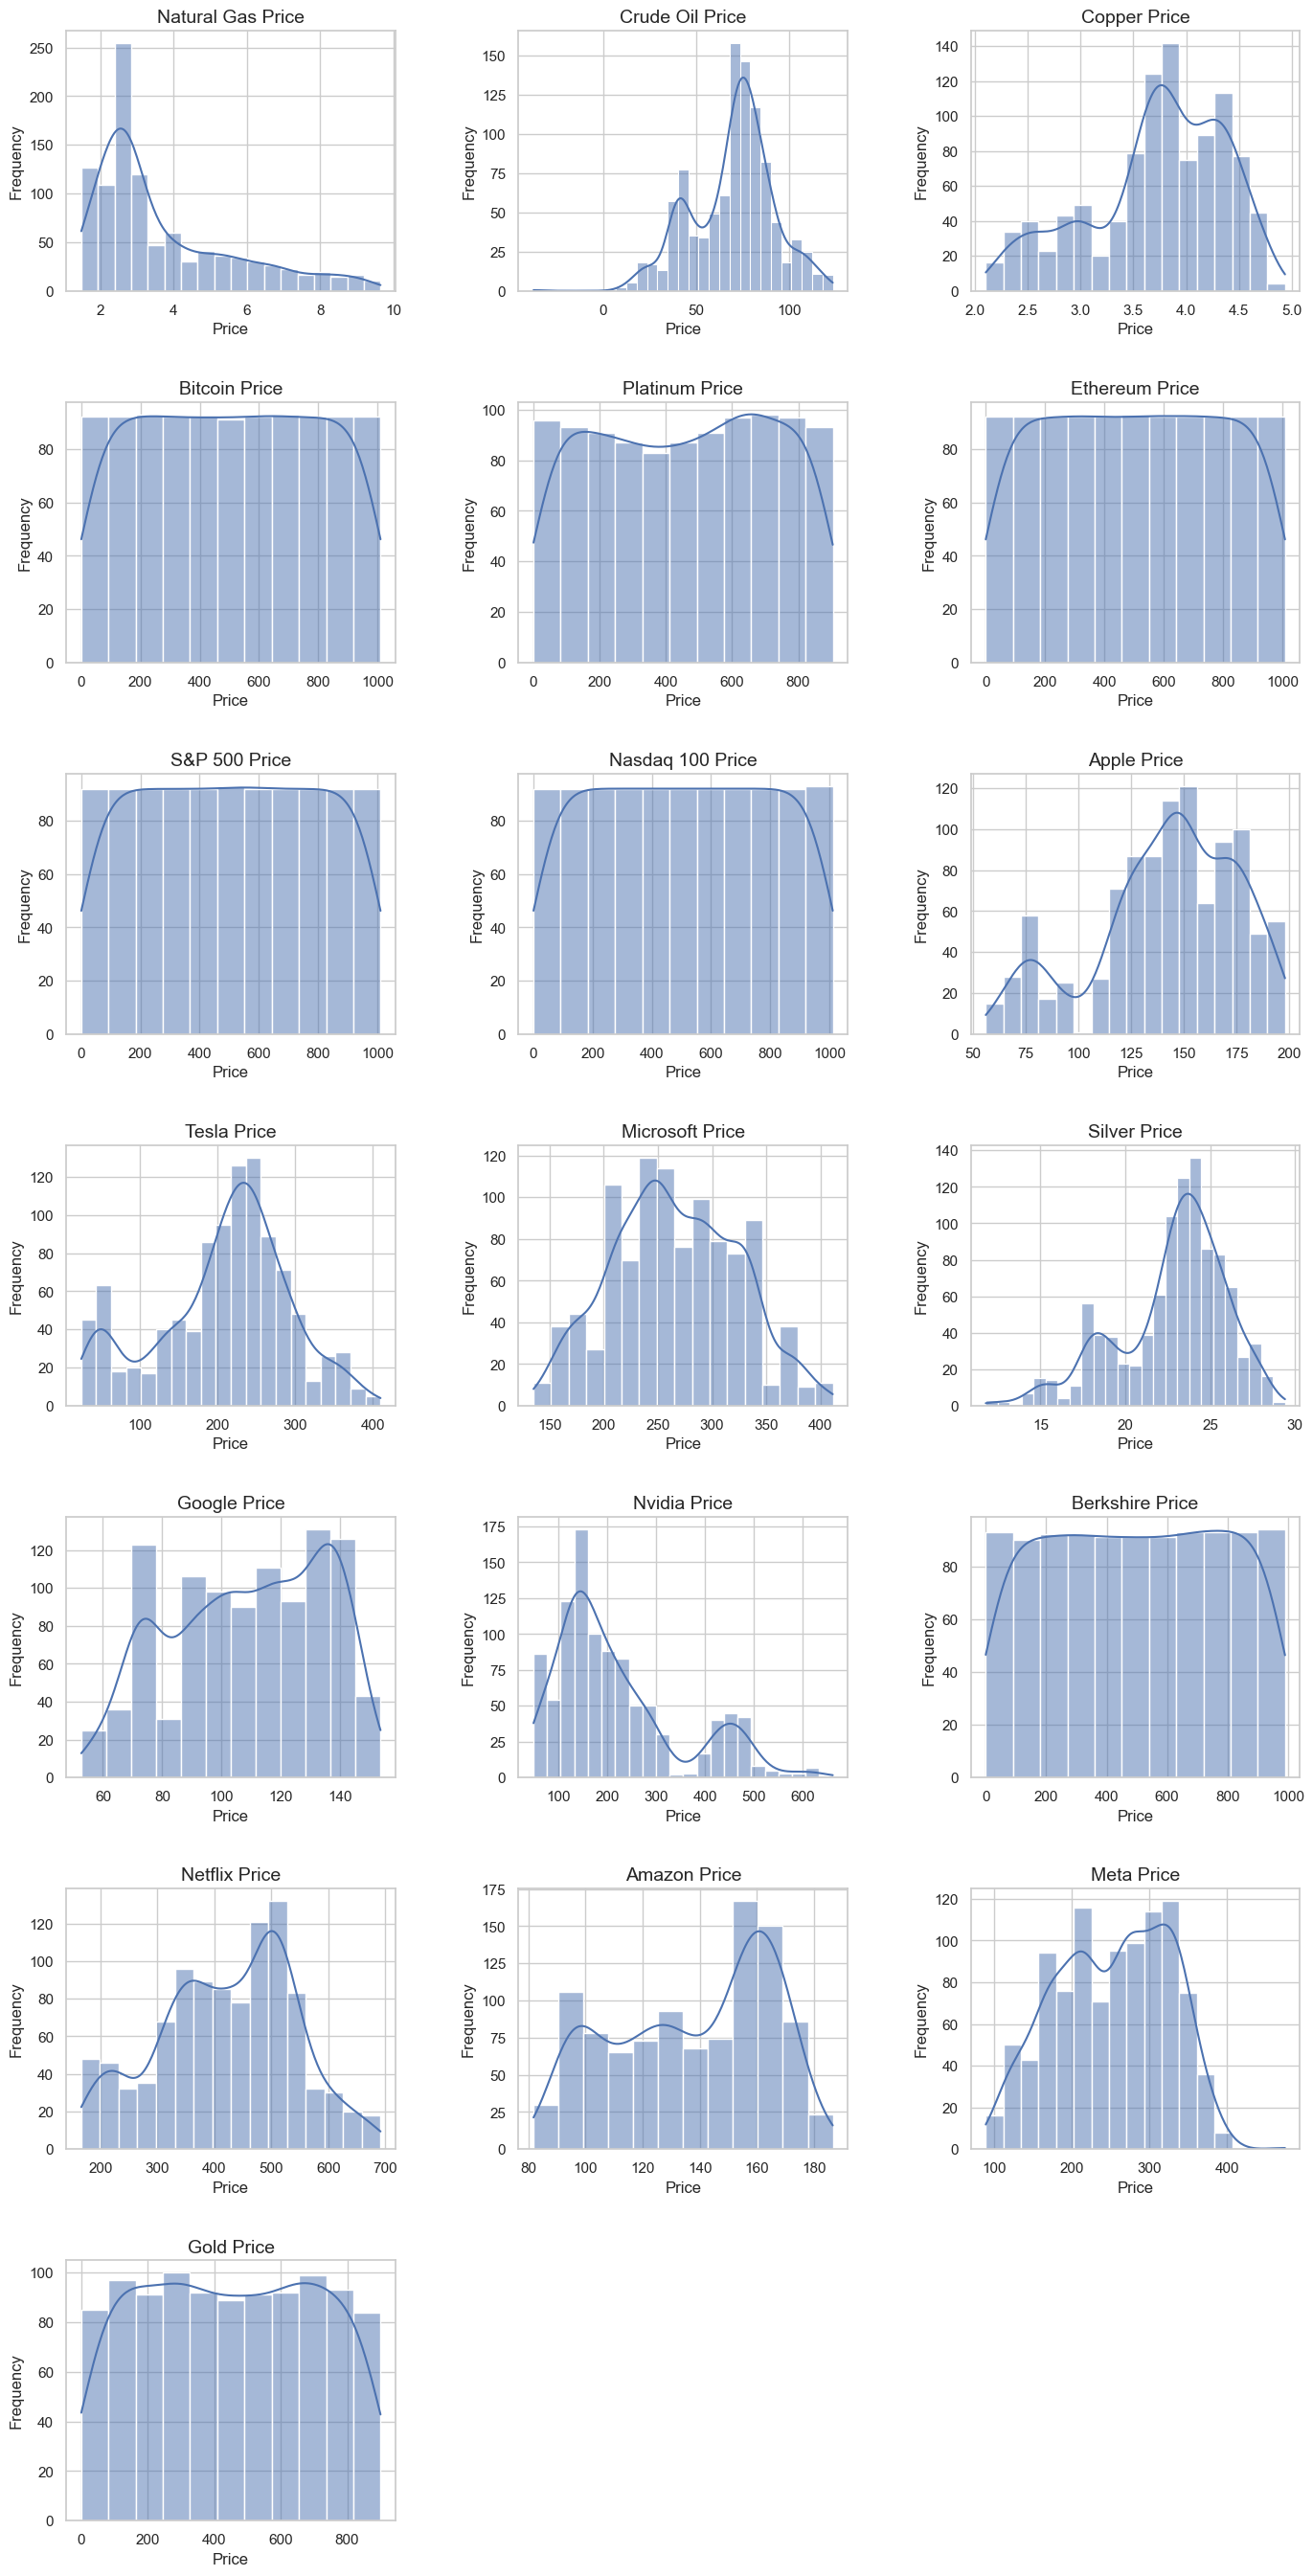

In [19]:
price_columns_new= [col for col in stocks_updated.columns if 'Price' in col]

import seaborn as sns

sns.set_theme(style="whitegrid")

n = len(price_columns_new)
ncols = 3
nrows = n // ncols + (n % ncols > 0)


fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows*4))
fig.tight_layout(pad=5.0)


for i, col in enumerate(price_columns_new):
    ax = axes.flat[i]
    sns.histplot(stocks_updated[col], kde=True, ax=ax)
    ax.set_title(col.replace('_', ' ').title(), fontsize=14)
    ax.set_xlabel('Price', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)


for j in range(i+1, nrows*ncols):
    axes.flat[j].set_visible(False)

plt.show()
fig.savefig("stock prices")